In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        continue;

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [3]:
# Cell 1: Imports & Environment Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import time
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, auc
)
from sklearn.preprocessing import label_binarize

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

2026-05-13 16:56:34.214376: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778691394.389958      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778691394.441836      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778691394.842899      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778691394.842936      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778691394.842939      57 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [4]:
# Cell 2: Dataset Path & Class Discovery
# Kaggle Brain Tumor MRI dataset path
DATASET_PATH = "/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset"

# Walk through directories to find train/test structure
for root, dirs, files in os.walk(DATASET_PATH):
    level = root.replace(DATASET_PATH, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 2:
        subindent = ' ' * 2 * (level + 1)
        for f in files[:3]:
            print(f'{subindent}{f}')

TRAIN_DIR = os.path.join(DATASET_PATH, "Training")
TEST_DIR  = os.path.join(DATASET_PATH, "Testing")

CLASS_NAMES = sorted(os.listdir(TRAIN_DIR))
NUM_CLASSES = len(CLASS_NAMES)
print(f"\nClasses ({NUM_CLASSES}): {CLASS_NAMES}")

# Count images per class
print("\nTraining set distribution:")
for cls in CLASS_NAMES:
    n = len(os.listdir(os.path.join(TRAIN_DIR, cls)))
    print(f"  {cls}: {n} images")

print("\nTest set distribution:")
for cls in CLASS_NAMES:
    n = len(os.listdir(os.path.join(TEST_DIR, cls)))
    print(f"  {cls}: {n} images")

brain-tumor-mri-dataset/
  Training/
    pituitary/
    notumor/
    meningioma/
    glioma/
  Testing/
    pituitary/
    notumor/
    meningioma/
    glioma/

Classes (4): ['glioma', 'meningioma', 'notumor', 'pituitary']

Training set distribution:
  glioma: 1400 images
  meningioma: 1400 images
  notumor: 1400 images
  pituitary: 1400 images

Test set distribution:
  glioma: 400 images
  meningioma: 400 images
  notumor: 400 images
  pituitary: 400 images


In [5]:
# Cell 3: Global Hyperparameters
IMG_SIZE    = (224, 224)   # ResNet50 expected input
BATCH_SIZE  = 32
EPOCHS_FE   = 10           # Feature Extraction phase
EPOCHS_FT   = 10           # Fine-Tuning phase
LR_FE       = 1e-3         # Learning rate for feature extraction
LR_FT       = 1e-5         # Lower LR for fine-tuning (avoid catastrophic forgetting)
SEED        = 42

print("Configuration:")
print(f"  Image Size   : {IMG_SIZE}")
print(f"  Batch Size   : {BATCH_SIZE}")
print(f"  Num Classes  : {NUM_CLASSES}")
print(f"  FE Epochs    : {EPOCHS_FE}")
print(f"  FT Epochs    : {EPOCHS_FT}")
print(f"  FE LR        : {LR_FE}")
print(f"  FT LR        : {LR_FT}")

Configuration:
  Image Size   : (224, 224)
  Batch Size   : 32
  Num Classes  : 4
  FE Epochs    : 10
  FT Epochs    : 10
  FE LR        : 0.001
  FT LR        : 1e-05


In the above cell, the main training settings for the ResNet50 model are shown. The image size is set to 224 by 224 because ResNet50 expects images in that format, so every MRI image will be resized to match the model input.

The batch size is 32, which means the model processes 32 images at a time before updating its weights. The epochs are split into two stages. The first stage is feature extraction, where the pretrained ResNet50 layers stay frozen and only the new classification layers learn. The second stage is fine tuning, where part of the base model is unfrozen so the network can adapt more closely to the MRI dataset.

The learning rate is higher during feature extraction because the new layers need to learn faster at the beginning. During fine tuning, the learning rate is reduced a lot so the model can make smaller and safer adjustments without forgetting what it already learned from ImageNet.

The seed is fixed at 42 to keep the results more consistent and reproducible when the data is split or shuffled. The number of classes comes from the dataset and tells the model how many categories it has to predict. Together, these values define the full training setup before the model actually starts learning.

In [6]:
# Cell 4: Data Augmentation & Generators
# ResNet50 expects inputs preprocessed with its specific function
train_datagen = ImageDataGenerator(
    preprocessing_function=keras.applications.resnet50.preprocess_input,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.15        # 15% of training set → validation
)

test_datagen = ImageDataGenerator(
    preprocessing_function=keras.applications.resnet50.preprocess_input
)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=SEED,
    shuffle=True
)

val_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=SEED,
    shuffle=False
)

test_gen = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f"\nTrain batches : {len(train_gen)}")
print(f"Val batches   : {len(val_gen)}")
print(f"Test batches  : {len(test_gen)}")
print(f"\nClass indices : {train_gen.class_indices}")

Found 4760 images belonging to 4 classes.
Found 840 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.

Train batches : 149
Val batches   : 27
Test batches  : 50

Class indices : {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In the above cell, the data pipeline for ResNet50 is prepared. The images are resized to the size expected by the model and passed through the same preprocessing function that ResNet50 was trained with originally.

It also adds light augmentation to the training data so the model sees slightly varied versions of the same images. That makes the training set more diverse and helps reduce overfitting, especially when the dataset is not very large. The validation and test generators are kept separate so the model is evaluated on data it has not seen during training.

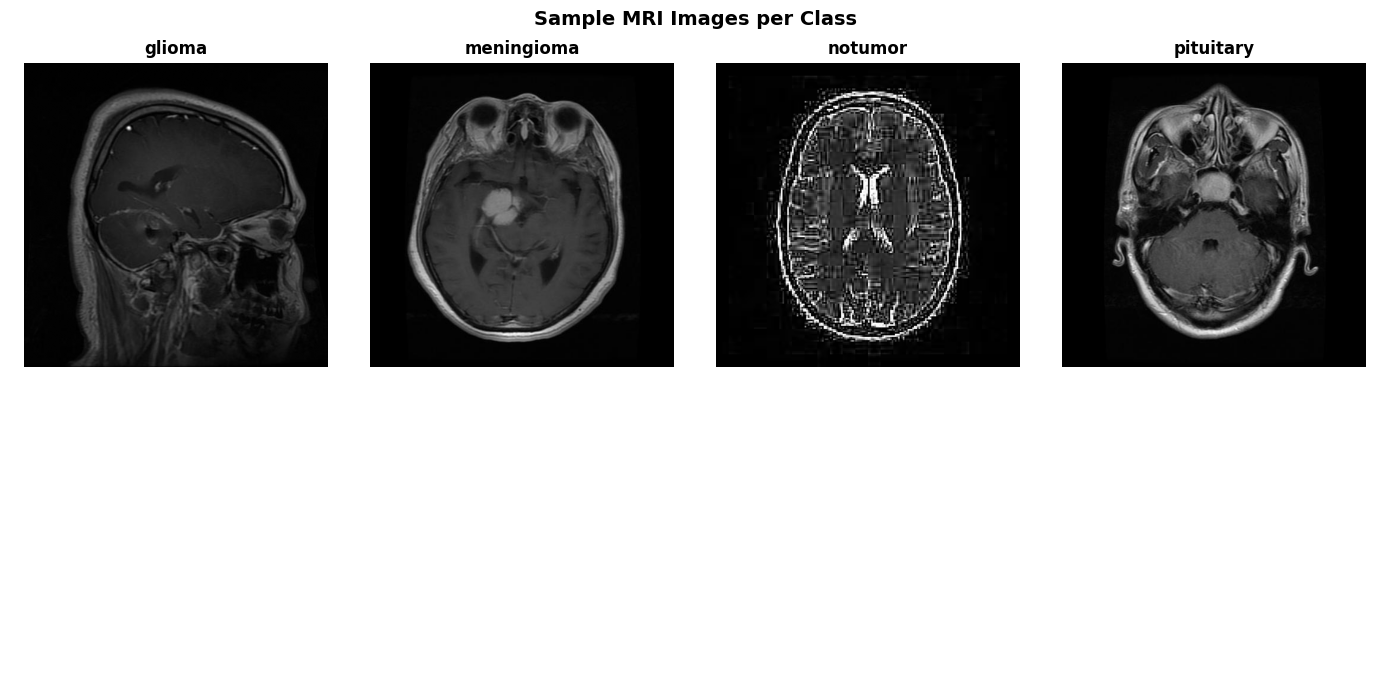

In [7]:
# Cell 5: Visualise Sample Images
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()

for i, cls in enumerate(CLASS_NAMES):
    cls_dir = os.path.join(TRAIN_DIR, cls)
    img_file = os.listdir(cls_dir)[0]
    img_path = os.path.join(cls_dir, img_file)
    img = plt.imread(img_path)
    axes[i].imshow(img, cmap='gray' if img.ndim == 2 else None)
    axes[i].set_title(cls, fontsize=12, fontweight='bold')
    axes[i].axis('off')

# Hide unused axes
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.suptitle("Sample MRI Images per Class", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("sample_images.png", dpi=150)
plt.show()

In the above cell, one example image from each class is shown so the dataset can be checked visually.

Seeing the samples early helps confirm that the classes are loaded correctly and that the MRI images look consistent with what the model will learn from. It is also a quick way to spot any issues with image quality, orientation, or class labeling before training starts.

In [8]:
# Cell 6: Load & Adapt ResNet50
# ── 2.6.1: Load pre-trained ResNet50, exclude top (FC) layers ──
base_model = ResNet50(
    weights='imagenet',
    include_top=False,              # Remove ImageNet 1000-class head
    input_shape=(*IMG_SIZE, 3)
)

print(f"ResNet50 base layers: {len(base_model.layers)}")
print(f"Base model output shape: {base_model.output_shape}")

# ── 2.6.1 / 2.6.2: Freeze entire base for Feature Extraction phase ──
base_model.trainable = False

frozen = sum(1 for l in base_model.layers if not l.trainable)
print(f"Frozen layers: {frozen}")

# ── Add new classification head for NUM_CLASSES ──
inputs = keras.Input(shape=(*IMG_SIZE, 3))
x = base_model(inputs, training=False)          # training=False keeps BN frozen
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation='relu', kernel_regularizer=keras.regularizers.l2(1e-4))(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(128, activation='relu', kernel_regularizer=keras.regularizers.l2(1e-4))(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)  # Match dataset classes

model = keras.Model(inputs, outputs)
model.summary()

I0000 00:00:1778691423.062901      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778691423.068913      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
ResNet50 base layers: 175
Base model output shape: (None, 7, 7, 2048)
Frozen layers: 175


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,153,860 (92.14 MB)

 Trainable params: 562,052 (2.14 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

In the above cell, the pretrained ResNet50 model is loaded without its original classification head and replaced with a new head designed for the tumor classes in this dataset.

At first the base network is frozen, which means the model uses ResNet50 as a fixed feature extractor while only the new layers learn the task specific patterns from the MRI images. This is useful because it lets the model reuse the general visual knowledge already learned from ImageNet while still adapting the final predictions to the current dataset.

In [9]:
# Cell 7: Feature Extraction Training (frozen base)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR_FE),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_fe = [
    EarlyStopping(patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_fe_model.keras', save_best_only=True, verbose=0)
]

print("=" * 50)
print("PHASE 1: Feature Extraction")
print("=" * 50)

start_fe = time.time()

history_fe = model.fit(
    train_gen,
    epochs=EPOCHS_FE,
    validation_data=val_gen,
    callbacks=callbacks_fe,
    verbose=1
)

end_fe = time.time()
fe_training_time = end_fe - start_fe

print(f"\n Feature Extraction Training Time: {fe_training_time:.2f}s "
      f"({fe_training_time/60:.2f} min)")
print(f"   Best Val Accuracy: {max(history_fe.history['val_accuracy']):.4f}")

PHASE 1: Feature Extraction
Epoch 1/10


I0000 00:00:1778691434.363430     158 service.cc:152] XLA service 0x791de40167f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778691434.363478     158 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778691434.363484     158 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778691436.286685     158 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/149 ━━━━━━━━━━━━━━━━━━━━ 36:45 15s/step - accuracy: 0.2812 - loss: 1.9314

I0000 00:00:1778691442.149090     158 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


149/149 ━━━━━━━━━━━━━━━━━━━━ 115s 675ms/step - accuracy: 0.6885 - loss: 0.9535 - val_accuracy: 0.8869 - val_loss: 0.4045 - learning_rate: 0.0010
Epoch 2/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 74s 494ms/step - accuracy: 0.8516 - loss: 0.4978 - val_accuracy: 0.9083 - val_loss: 0.3345 - learning_rate: 0.0010
Epoch 3/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 68s 457ms/step - accuracy: 0.8723 - loss: 0.4222 - val_accuracy: 0.9143 - val_loss: 0.3132 - learning_rate: 0.0010
Epoch 4/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 72s 480ms/step - accuracy: 0.8872 - loss: 0.3719 - val_accuracy: 0.9155 - val_loss: 0.3217 - learning_rate: 0.0010
Epoch 5/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 77s 520ms/step - accuracy: 0.8852 - loss: 0.3817 - val_accuracy: 0.9095 - val_loss: 0.3065 - learning_rate: 0.0010
Epoch 6/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 74s 494ms/step - accuracy: 0.8982 - loss: 0.3538 - val_accuracy: 0.9107 - val_loss: 0.2898 - learning_rate: 0.0010
Epoch 7/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 65s 439ms/step - accuracy: 0.9065 - loss

In the above cell, only the new classification head is trained while the ResNet50 backbone stays frozen. That is the feature extraction stage, where the model learns the dataset labels without changing the pretrained image features too much.

The callbacks watch validation performance, stop training if the model stops improving, reduce the learning rate when progress slows, and save the best version of the model. Together, they help the model train more efficiently, avoid overfitting, and keep the strongest checkpoint for later evaluation.

In [10]:
# Cell 8: Fine-Tuning (unfreeze top ResNet layers)
# ── 2.6.2: Unfreeze last 30 layers of ResNet50 ──
base_model.trainable = True

# Selectively unfreeze — keep early layers frozen (low-level features)
UNFREEZE_FROM = len(base_model.layers) - 30
for i, layer in enumerate(base_model.layers):
    layer.trainable = (i >= UNFREEZE_FROM)

trainable = sum(1 for l in model.layers if l.trainable)
print(f"Trainable layers after unfreezing: {trainable}")

# Recompile with lower LR to avoid catastrophic forgetting
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR_FT),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_ft = [
    EarlyStopping(patience=7, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(factor=0.3, patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint('best_ft_model.keras', save_best_only=True, verbose=0)
]

print("=" * 50)
print("PHASE 2: Fine-Tuning")
print("=" * 50)

start_ft = time.time()

history_ft = model.fit(
    train_gen,
    epochs=EPOCHS_FT,
    validation_data=val_gen,
    callbacks=callbacks_ft,
    verbose=1
)

end_ft = time.time()
ft_training_time = end_ft - start_ft

print(f"\n Fine-Tuning Training Time: {ft_training_time:.2f}s "
      f"({ft_training_time/60:.2f} min)")
print(f"   Total Training Time: {(fe_training_time + ft_training_time)/60:.2f} min")
print(f"   Best Val Accuracy: {max(history_ft.history['val_accuracy']):.4f}")

Trainable layers after unfreezing: 9
PHASE 2: Fine-Tuning
Epoch 1/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 100s 536ms/step - accuracy: 0.9073 - loss: 0.3425 - val_accuracy: 0.9393 - val_loss: 0.2562 - learning_rate: 1.0000e-05
Epoch 2/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 67s 448ms/step - accuracy: 0.9293 - loss: 0.2749 - val_accuracy: 0.9333 - val_loss: 0.2515 - learning_rate: 1.0000e-05
Epoch 3/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 66s 444ms/step - accuracy: 0.9387 - loss: 0.2415 - val_accuracy: 0.9381 - val_loss: 0.2546 - learning_rate: 1.0000e-05
Epoch 4/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 72s 485ms/step - accuracy: 0.9465 - loss: 0.2319 - val_accuracy: 0.9452 - val_loss: 0.2278 - learning_rate: 1.0000e-05
Epoch 5/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 68s 453ms/step - accuracy: 0.9557 - loss: 0.1966 - val_accuracy: 0.9429 - val_loss: 0.2412 - learning_rate: 1.0000e-05
Epoch 6/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 68s 454ms/step - accuracy: 0.9534 - loss: 0.2142 - val_accuracy: 0.9571 - val_loss: 0.2024 - learning_rate

In the above cell, the model is switched into fine tuning mode by unfreezing the last part of ResNet50. The idea is to let the deeper layers adapt to the MRI dataset while keeping the earlier layers stable.

A much smaller learning rate is used here so the model can make careful updates. That lowers the risk of damaging the useful features it already learned during the first training stage and usually gives a better final result. This second stage is where the model can improve its performance more gradually and become more specific to the medical images.

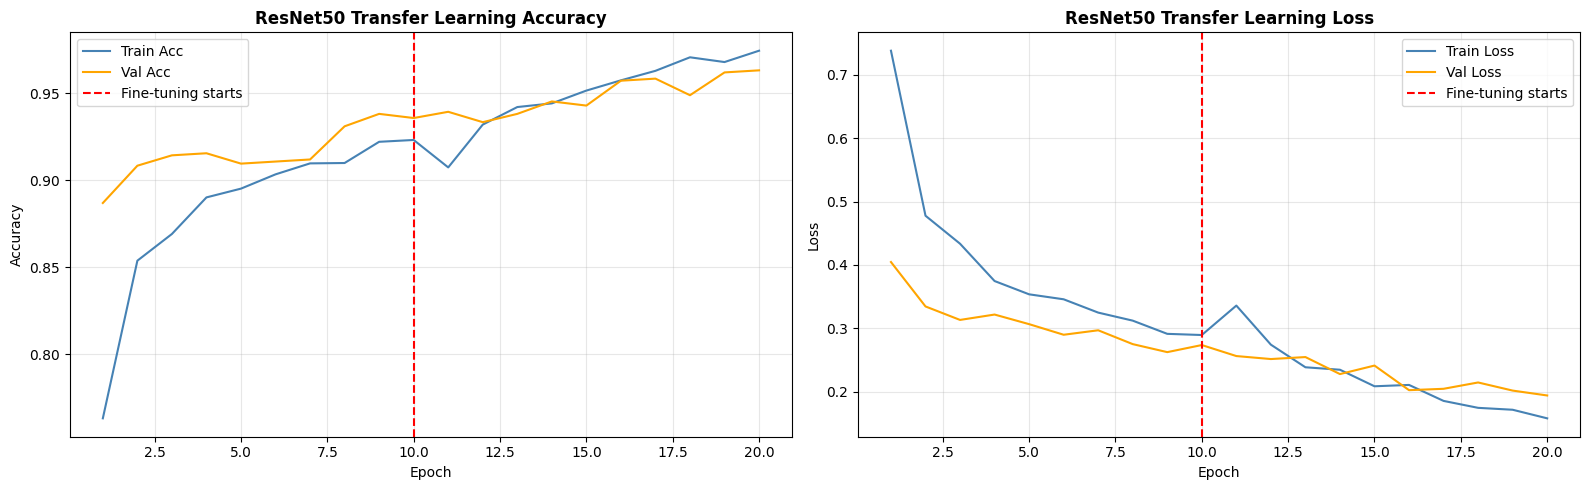

In [11]:
# Cell 9: Training History Plots (both phases)
def plot_history(hist1, hist2, title_prefix=""):
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Combine histories
    acc    = hist1.history['accuracy']    + hist2.history['accuracy']
    val_acc= hist1.history['val_accuracy']+ hist2.history['val_accuracy']
    loss   = hist1.history['loss']        + hist2.history['loss']
    val_loss=hist1.history['val_loss']    + hist2.history['val_loss']
    
    ep1 = len(hist1.history['accuracy'])
    epochs_total = range(1, len(acc) + 1)

    # Accuracy
    axes[0].plot(epochs_total, acc,     label='Train Acc',  color='steelblue')
    axes[0].plot(epochs_total, val_acc, label='Val Acc',    color='orange')
    axes[0].axvline(ep1, color='red', linestyle='--', label='Fine-tuning starts')
    axes[0].set_title(f'{title_prefix} Accuracy', fontweight='bold')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    # Loss
    axes[1].plot(epochs_total, loss,     label='Train Loss', color='steelblue')
    axes[1].plot(epochs_total, val_loss, label='Val Loss',   color='orange')
    axes[1].axvline(ep1, color='red', linestyle='--', label='Fine-tuning starts')
    axes[1].set_title(f'{title_prefix} Loss', fontweight='bold')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig("training_curves.png", dpi=150)
    plt.show()

plot_history(history_fe, history_ft, title_prefix="ResNet50 Transfer Learning")

In the above cell, the training history from both stages is combined and accuracy and loss are plotted across the full run.

The vertical marker shows where fine tuning begins, so it becomes easier to see how much the second stage improves the model compared with the initial feature extraction stage. This plot is useful for checking whether the model is learning steadily or starting to overfit. If the training and validation curves move far apart, that usually means the model is not generalising as well as it should.

In [12]:
# Cell 10: Model Evaluation — Test Set Metrics
print("=" * 50)
print("EVALUATION ON TEST SET")
print("=" * 50)

# Load best model
model = keras.models.load_model('best_ft_model.keras')

# Get predictions
test_gen.reset()
y_pred_prob = model.predict(test_gen, verbose=1)
y_pred       = np.argmax(y_pred_prob, axis=1)
y_true       = test_gen.classes

# Core metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='weighted')
rec  = recall_score(y_true, y_pred, average='weighted')
f1   = f1_score(y_true, y_pred, average='weighted')

# AUC (multi-class One-vs-Rest)
y_true_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
auc_score  = roc_auc_score(y_true_bin, y_pred_prob, multi_class='ovr', average='weighted')

print(f"\n{'Metric':<25} {'Score':>10}")
print("-" * 37)
print(f"{'Accuracy':<25} {acc:>10.4f}")
print(f"{'Precision (weighted)':<25} {prec:>10.4f}")
print(f"{'Recall (weighted)':<25} {rec:>10.4f}")
print(f"{'F1-Score (weighted)':<25} {f1:>10.4f}")
print(f"{'ROC-AUC (weighted OvR)':<25} {auc_score:>10.4f}")
print(f"\n{'Feature Extraction Time':<25} {fe_training_time/60:>9.2f}m")
print(f"{'Fine-Tuning Time':<25} {ft_training_time/60:>9.2f}m")
print(f"{'Total Training Time':<25} {(fe_training_time+ft_training_time)/60:>9.2f}m")

# Full per-class report
print("\nDetailed Classification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

EVALUATION ON TEST SET
50/50 ━━━━━━━━━━━━━━━━━━━━ 13s 194ms/step

Metric                         Score
-------------------------------------
Accuracy                      0.9263
Precision (weighted)          0.9290
Recall (weighted)             0.9263
F1-Score (weighted)           0.9245
ROC-AUC (weighted OvR)        0.9852

Feature Extraction Time       12.64m
Fine-Tuning Time              11.75m
Total Training Time           24.40m

Detailed Classification Report:
              precision    recall  f1-score   support

      glioma       0.97      0.79      0.87       400
  meningioma       0.87      0.93      0.90       400
     notumor       0.93      1.00      0.96       400
   pituitary       0.95      0.99      0.97       400

    accuracy                           0.93      1600
   macro avg       0.93      0.93      0.92      1600
weighted avg       0.93      0.93      0.92      1600



In the above cell, the final saved model is evaluated on the test set and the main performance measures are calculated.

The printed output gives a numeric summary of how well the model performed on unseen test images. Accuracy tells how often the model was correct overall. Precision shows how often a predicted class was truly that class. Recall shows how many real examples of a class the model managed to find. F1 score combines precision and recall into one balanced measure. The ROC AUC score adds another view of how strongly the model separates the classes. The detailed classification report then breaks the results down class by class, so it becomes easier to see which tumor categories were predicted well and which ones were harder for the model.

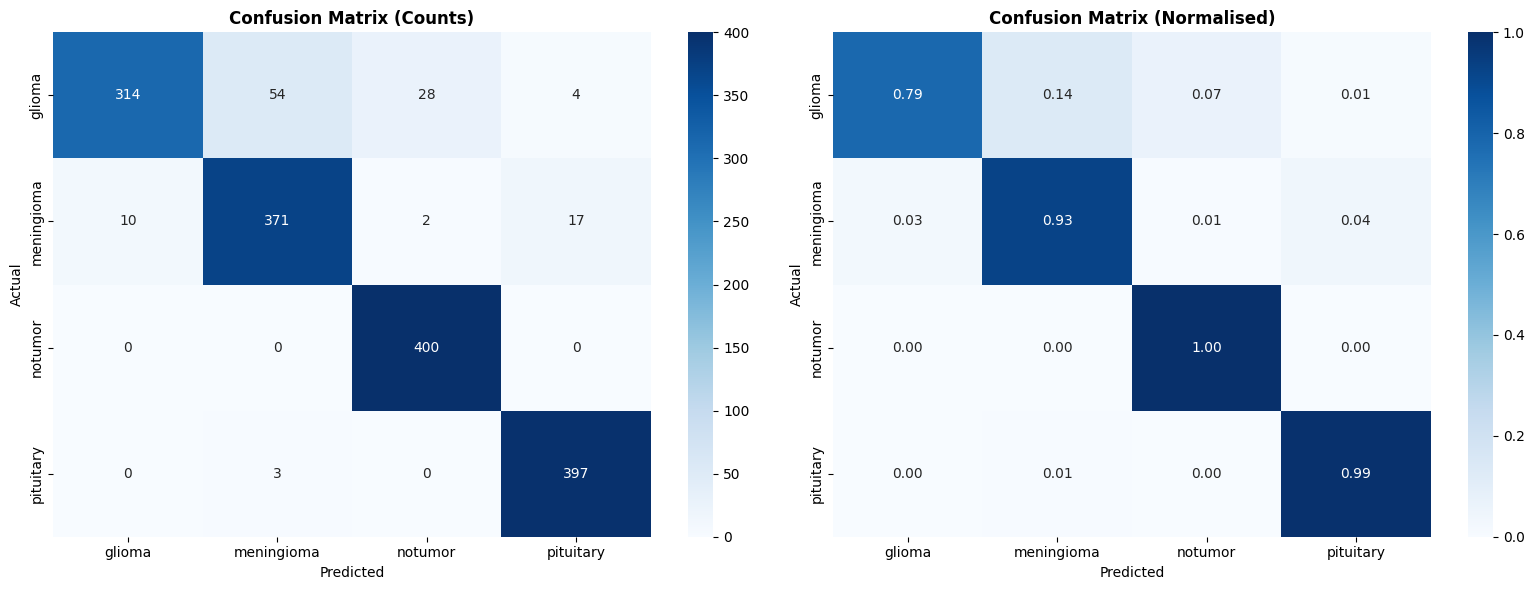

In [13]:
# Cell 11: Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_title('Confusion Matrix (Counts)', fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

# Normalised
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
axes[1].set_title('Confusion Matrix (Normalised)', fontweight='bold')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

In the above cell, the test predictions are turned into a confusion matrix so the mistakes are easier to see.

The graph on the left shows the raw number of predictions. The cells on the diagonal are the correct predictions, while the off diagonal cells show where the model confused one class with another. The graph on the right shows the same information in normalised form, so each row adds up to one hundred percent. That makes it easier to compare classes even when they do not have the same number of test images. Together, the two plots show not only how accurate the model is, but also which classes are being mixed up most often.

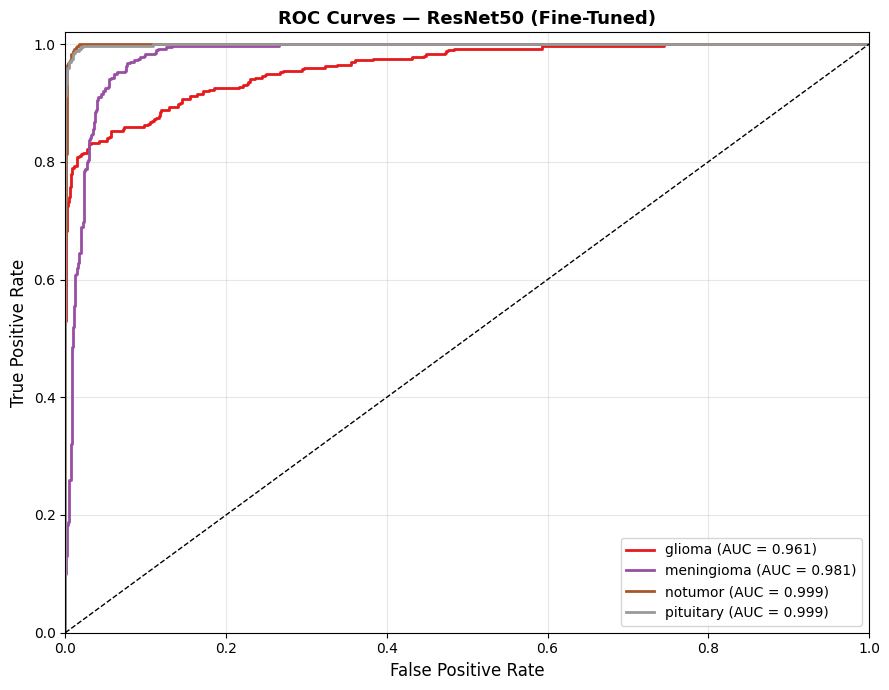

In [14]:
# Cell 12: ROC Curves per Class
fig, ax = plt.subplots(figsize=(9, 7))
colors = plt.cm.Set1(np.linspace(0, 1, NUM_CLASSES))

for i, (cls, color) in enumerate(zip(CLASS_NAMES, colors)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_prob[:, i])
    roc_auc     = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f'{cls} (AUC = {roc_auc:.3f})')

ax.plot([0,1], [0,1], 'k--', lw=1)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — ResNet50 (Fine-Tuned)', fontweight='bold', fontsize=13)
ax.legend(loc='lower right')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("roc_curves.png", dpi=150)
plt.show()

In the above cell, ROC curves are drawn for each class so the separation ability of the model can be examined one class at a time.

Each curve shows the trade off between false positive rate and true positive rate for one class against all the others. A curve that stays closer to the top left corner usually means the model is better at distinguishing that class from the others. The dashed diagonal line is the baseline for random guessing, so any curve above it means the model is doing better than chance. The AUC value next to each curve gives a compact summary of that class specific performance, with larger values showing stronger separation.

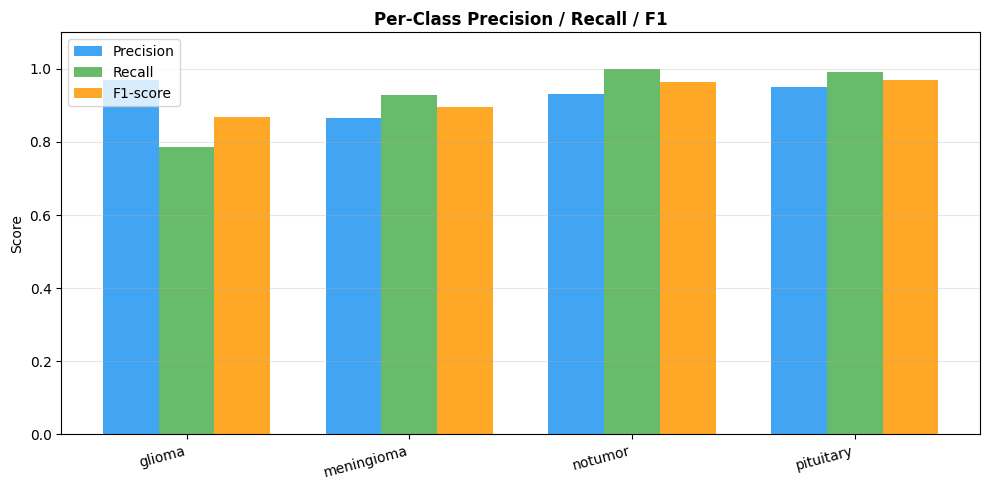

In [15]:
# Cell 13: Per-Class Metrics Visualisation
report = classification_report(
    y_true, y_pred, target_names=CLASS_NAMES, output_dict=True
)
report_df = pd.DataFrame(report).T.iloc[:NUM_CLASSES][['precision','recall','f1-score']]

fig, ax = plt.subplots(figsize=(10, 5))
x   = np.arange(len(CLASS_NAMES))
w   = 0.25
colors_bar = ['#2196F3', '#4CAF50', '#FF9800']

for i, (col, color) in enumerate(zip(report_df.columns, colors_bar)):
    ax.bar(x + i*w, report_df[col], w, label=col.capitalize(), color=color, alpha=0.85)

ax.set_xticks(x + w)
ax.set_xticklabels(CLASS_NAMES, rotation=15, ha='right')
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Per-Class Precision / Recall / F1', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("per_class_metrics.png", dpi=150)
plt.show()

In the above cell, the classification report is turned into a bar chart so precision, recall, and F1 score can be compared across classes more easily.

Each group of bars represents one class, and the three colours show precision, recall, and F1 score for that class. This makes it easy to compare performance across categories at a glance. A class with high bars across all three metrics is being learned well, while a class with a lower bar in one metric may still need improvement. The chart is useful because it shows the same information as the report, but in a simpler visual form.

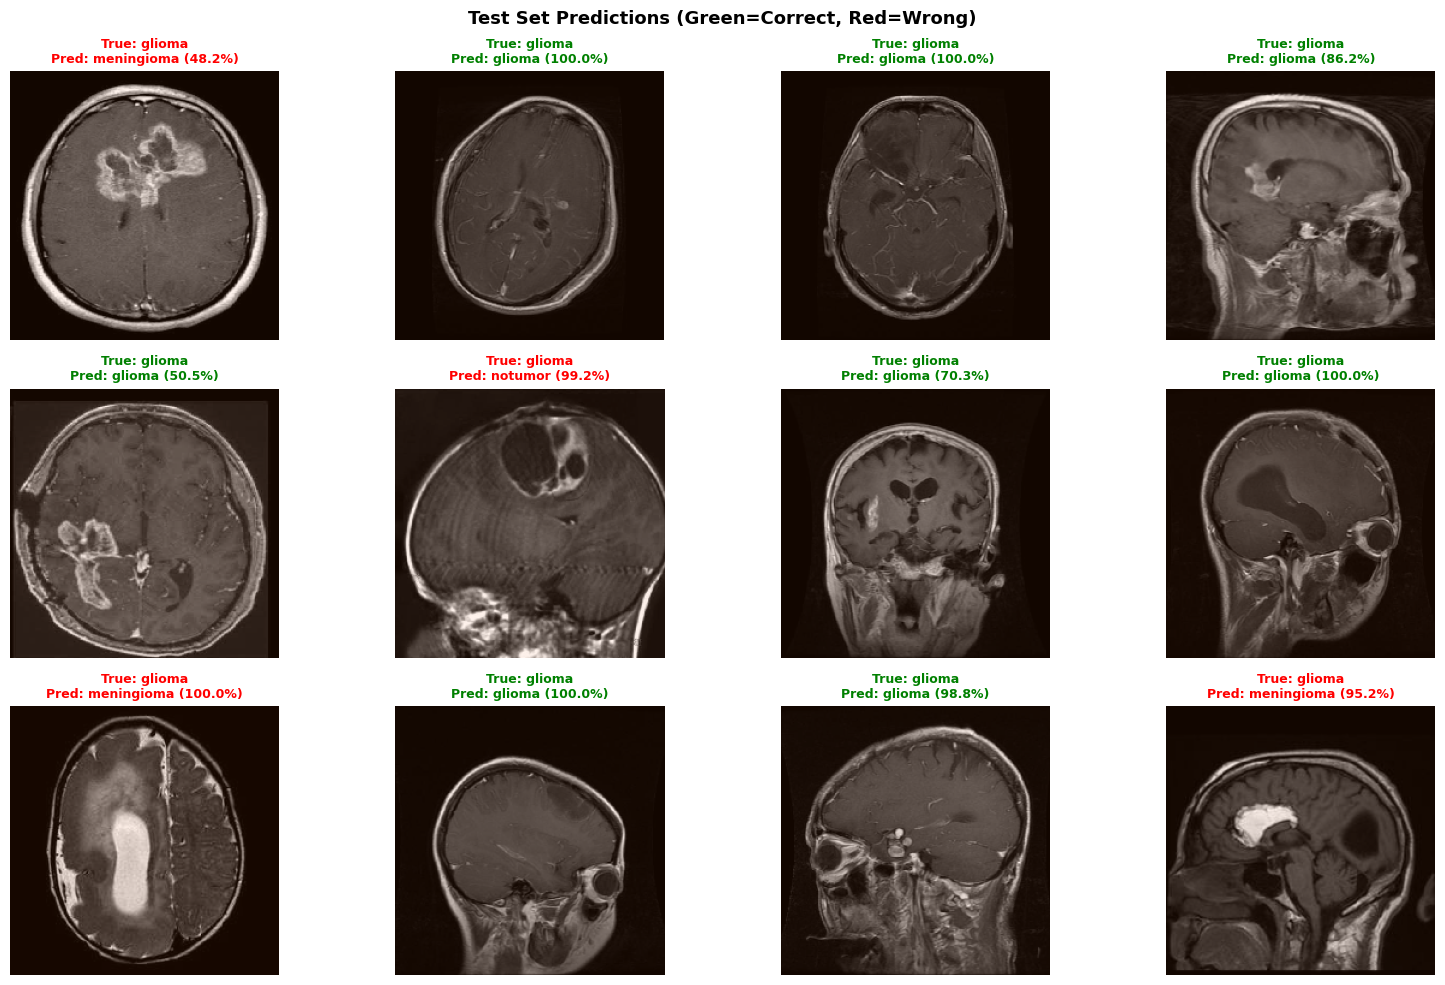

In [16]:
# Cell 14: Visual Predictions on Test Samples
test_gen.reset()
images, labels = next(test_gen)
preds = model.predict(images, verbose=0)

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i in range(min(12, len(images))):
    # Reverse ResNet preprocessing for display
    display_img = images[i].copy()
    display_img = (display_img - display_img.min()) / (display_img.max() - display_img.min())
    
    true_label = CLASS_NAMES[np.argmax(labels[i])]
    pred_label = CLASS_NAMES[np.argmax(preds[i])]
    conf       = np.max(preds[i]) * 100
    
    axes[i].imshow(display_img)
    color = 'green' if true_label == pred_label else 'red'
    axes[i].set_title(
        f"True: {true_label}\nPred: {pred_label} ({conf:.1f}%)",
        color=color, fontsize=9, fontweight='bold'
    )
    axes[i].axis('off')

plt.suptitle("Test Set Predictions (Green=Correct, Red=Wrong)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("prediction_samples.png", dpi=150)
plt.show()

In the above cell, a small set of test images is shown together with the model predictions.

The color of each title helps highlight whether the prediction is correct or not, and the confidence score shows how certain the model was about its answer. This is useful for checking the model in a more practical way, not just through summary numbers. It also helps you see whether the prediction looks reasonable when compared with the actual image. If the prediction is correct with a high confidence score, the model is behaving well on that sample. If it is wrong or uncertain, that suggests a case where the model may still struggle.

In [17]:
# Cell 15: Final Summary Table

print("       TRANSFER LEARNING RESULTS SUMMARY — ResNet50")


summary = {
    "Model"                  : "ResNet50 (ImageNet → Brain Tumor MRI)",
    "Input Size"             : f"{IMG_SIZE[0]}×{IMG_SIZE[1]}",
    "Num Classes"            : NUM_CLASSES,
    "Feature Extraction LR"  : LR_FE,
    "Fine-Tuning LR"         : LR_FT,
    "Test Accuracy"          : f"{acc:.4f}",
    "Weighted Precision"     : f"{prec:.4f}",
    "Weighted Recall"        : f"{rec:.4f}",
    "Weighted F1-Score"      : f"{f1:.4f}",
    "Weighted ROC-AUC"       : f"{auc_score:.4f}",
    "FE Training Time"       : f"{fe_training_time/60:.2f} min",
    "Fine-Tuning Time"       : f"{ft_training_time/60:.2f} min",
    "Total Training Time"    : f"{(fe_training_time+ft_training_time)/60:.2f} min",
}

for k, v in summary.items():
    print(f"  {k:<30} {str(v):>20}")



       TRANSFER LEARNING RESULTS SUMMARY — ResNet50
  Model                          ResNet50 (ImageNet → Brain Tumor MRI)
  Input Size                                  224×224
  Num Classes                                       4
  Feature Extraction LR                         0.001
  Fine-Tuning LR                                1e-05
  Test Accuracy                                0.9263
  Weighted Precision                           0.9290
  Weighted Recall                              0.9263
  Weighted F1-Score                            0.9245
  Weighted ROC-AUC                             0.9852
  FE Training Time                          12.64 min
  Fine-Tuning Time                          11.75 min
  Total Training Time                       24.40 min


In the above cell, the final experiment results are collected into one summary block.

It brings together the model settings, the main test metrics, and the training times so the overall outcome of the transfer learning run is easy to read in one place. This makes the final result simple to review without going back through every earlier output, which is helpful when writing the conclusion of the notebook.